In [1]:
#import relevant libraries
import os
import NLProcessing
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from textwrap import wrap



#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 15.83it/s]


Numba compilation complete!


In [2]:
#initial file processing
workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Climbing_New\\"
specifiedpath = homecomp
openPath = specifiedpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [3]:
#for fonts only
from matplotlib import font_manager

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

In [4]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## Function

In [129]:

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

## Code

## table of metrics for lin reg

In [130]:
newfile2 = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx"
onlymeans = pd.read_excel(newfile2)


onlymeans.columns.tolist()

['MBON',
 'Fall number_ΔΔ',
 'Speed_Δg',
 'Average height climbed_Δg',
 'Bout speed_Δg',
 'Pause position_Δg',
 'Max velocity_Δg',
 'Straightness Index_Δg',
 'Duration of bouts_Δg',
 'Number of Bouts_Δg',
 'Log2 Bout Speed ratio_Hg',
 'Log2 Speed ratio_Hg',
 'Bout Number index_Hg',
 'Bout Duration ratio_Hg',
 'Max Velocity ratio_Hg',
 'responder',
 'genotypeandresponder']

In [ ]:
responder = "ACR"

newfile2 = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx"
onlymeans = pd.read_excel(newfile2)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics= ['MBON', 'Fall number_ΔΔ',
 'Average height climbed_Δg',
 'Straightness Index_Δg',
 'Log2 Bout Speed ratio_Hg',
 'Log2 Speed ratio_Hg',
 'Bout Number index_Hg',
 'Bout Duration ratio_Hg',
 'Max Velocity ratio_Hg', 'responder']

specificmetricsdf = mbononly[[col for col in mbononly.columns if col in specificmetrics]]

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = specificmetricsdf[specificmetricsdf['responder']=="Chrimson2"].reset_index(drop=True)
    colormarker = "red"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = specificmetricsdf[specificmetricsdf['responder']=="ACR"].reset_index(drop=True)
    colormarker = "green"

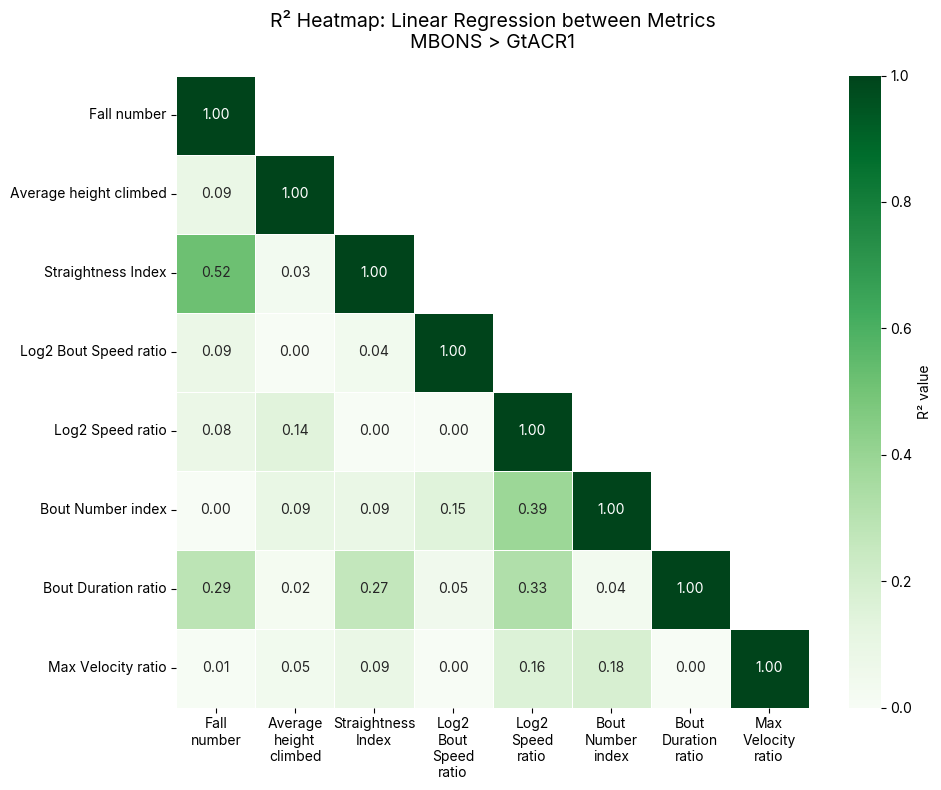

In [146]:
from scipy.stats import linregress

df_linreg = df_specificmbon.drop(['responder', 'MBON'], axis =1)
df_linreg.columns = [col.split('_')[0] for col in df_linreg.columns]
n_metrics = len(df_linreg.columns)
r2_matrix = np.zeros((n_metrics, n_metrics))

for i in range(n_metrics):
    for j in range(n_metrics):
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r2_matrix[i, j] = r_value**2
        
r2_df = pd.DataFrame(r2_matrix, 
                     columns=df_linreg.columns, 
                     index=df_linreg.columns)

mask = np.triu(np.ones_like(r2_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
hmap = sns.heatmap(r2_df, annot=True, fmt='.2f', cmap=cmapcolor, 
            vmin=0, vmax=1, center=0.5,
            cbar_kws={'label': 'R² value'},
            square=True, linewidths=0.5, ax=ax,
            mask=mask)  

plt.title(f"R² Heatmap: Linear Regression between Metrics\nMBONS > {responderrename}", 
          fontsize=14, pad=20)
plt.xticks(rotation=0)
NLProcessing.wrap_labels(hmap, 5)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## lin reg of metrics

In [107]:
newfile2 = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx"
onlymeans = pd.read_excel(newfile2)


onlymeans.columns.tolist()

['MBON',
 'Fall number_ΔΔ',
 'Speed_Δg',
 'Average height climbed_Δg',
 'Bout speed_Δg',
 'Pause position_Δg',
 'Max velocity_Δg',
 'Straightness Index_Δg',
 'Duration of bouts_Δg',
 'Number of Bouts_Δg',
 'Log2 Bout Speed ratio_Hg',
 'Log2 Speed ratio_Hg',
 'Bout Number index_Hg',
 'Bout Duration ratio_Hg',
 'Max Velocity ratio_Hg',
 'responder',
 'genotypeandresponder']

In [ ]:
## Falling only
responder = "ACR"

newfile2 = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx"
onlymeans = pd.read_excel(newfile2)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics= ['MBON', 'Fall number_ΔΔ',
 'Average height climbed_Δg',
 'Straightness Index_Δg',
 'Log2 Bout Speed ratio_Hg',
 'Log2 Speed ratio_Hg',
 'Bout Number index_Hg',
 'Bout Duration ratio_Hg',
 'Max Velocity ratio_Hg', 'responder']


specificmetricsdf = mbononly[[col for col in mbononly.columns if col in specificmetrics]]

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = specificmetricsdf[specificmetricsdf['responder']=="Chrimson2"].reset_index(drop=True)
    colormarker = "red"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = specificmetricsdf[specificmetricsdf['responder']=="ACR"].reset_index(drop=True)
    colormarker = "green"

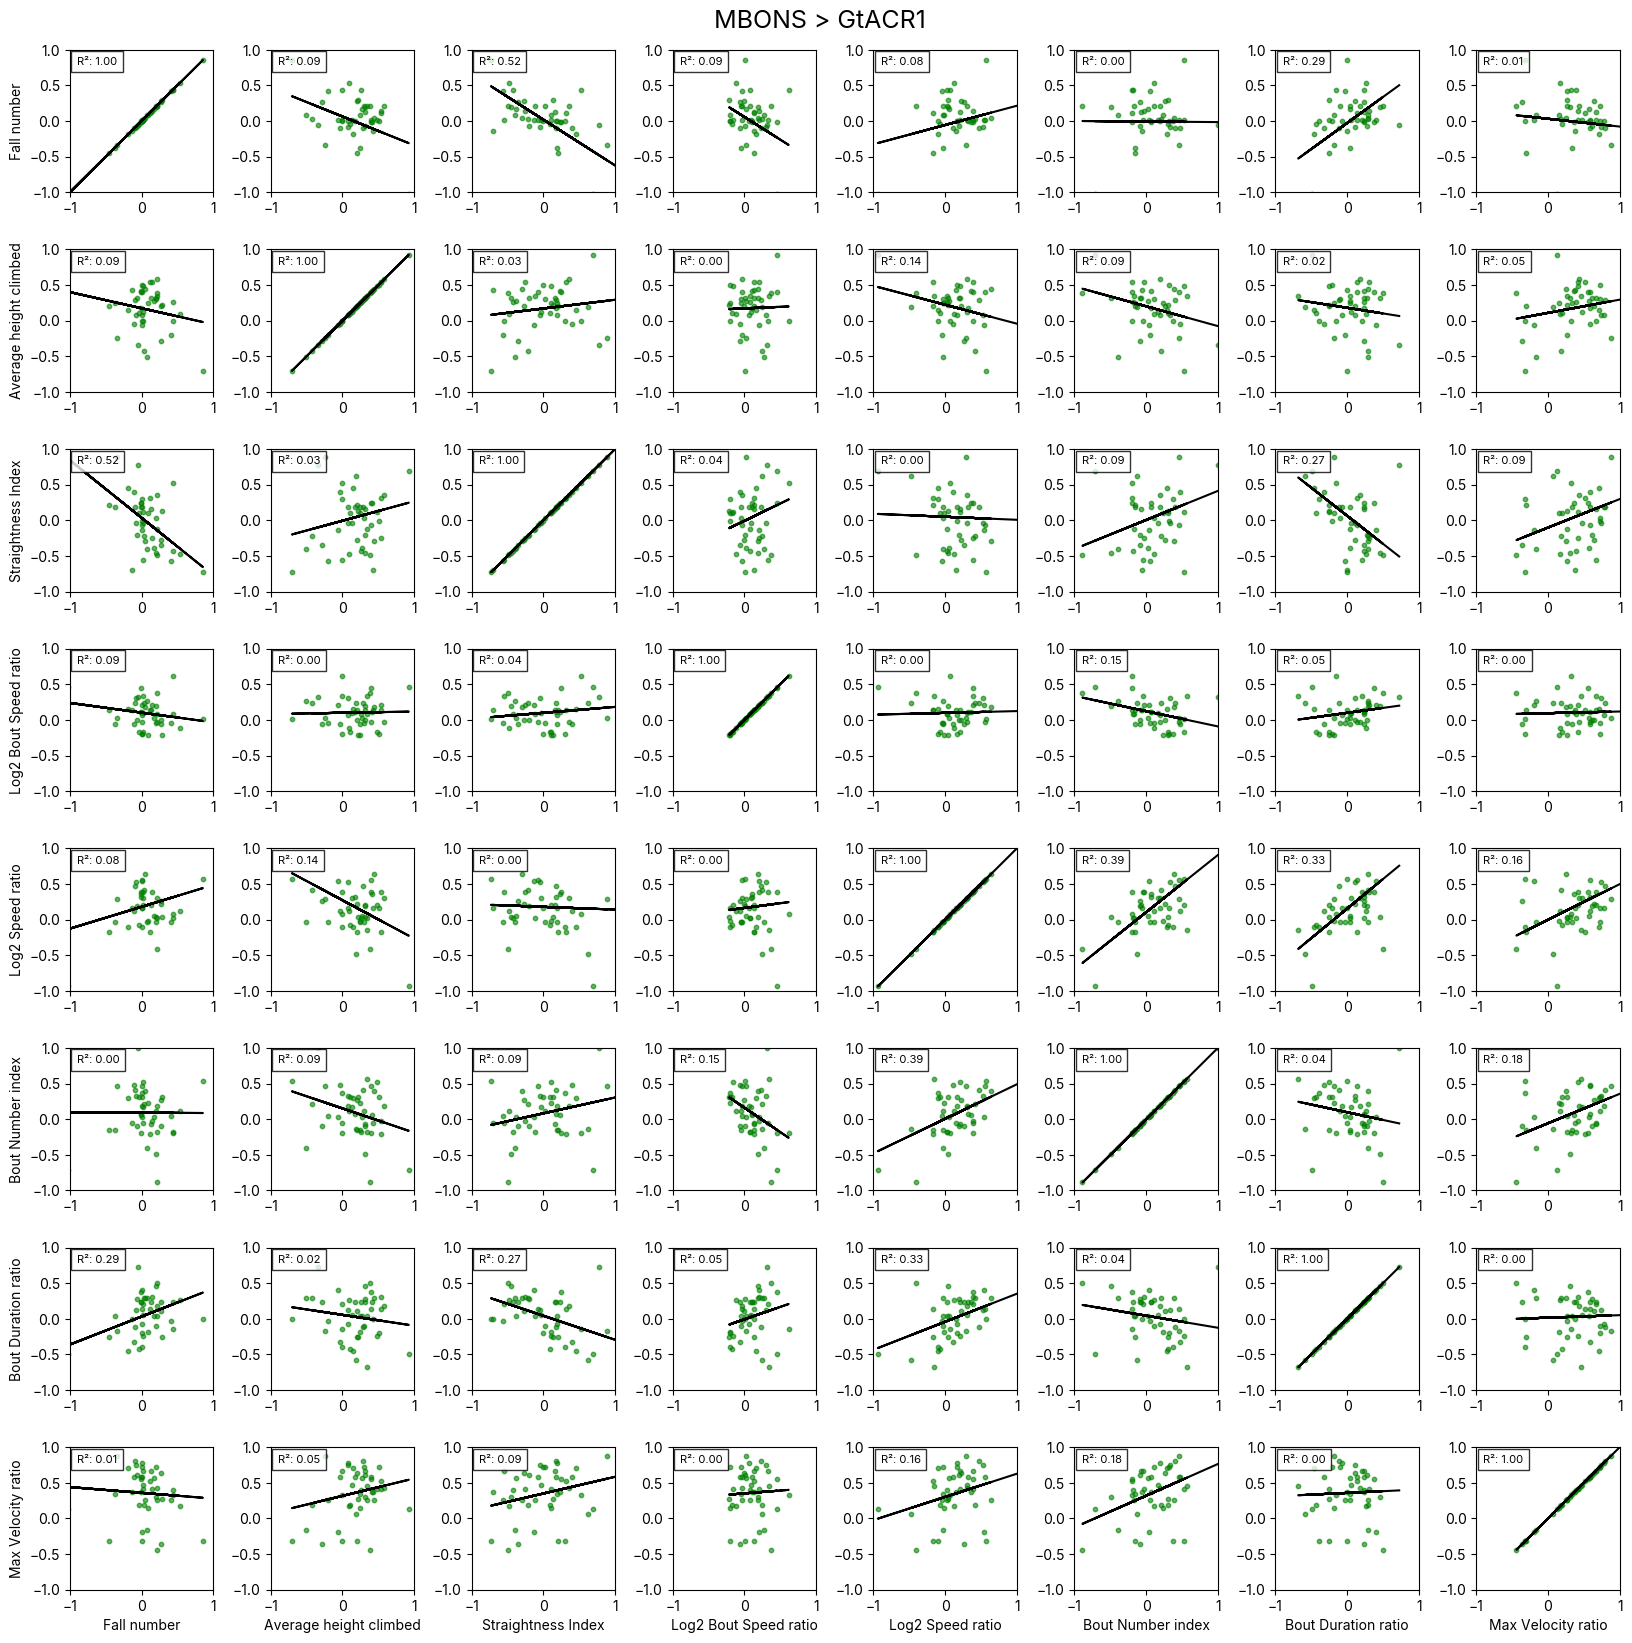

In [115]:
# Create a figure and axis grid
from scipy.stats import linregress, pearsonr, t

fig, axes = plt.subplots(8, 8, figsize=(20, 20), gridspec_kw={'wspace': 0.4, 'hspace': 0.4})

df_linreg = df_specificmbon.drop(['responder', 'MBON'], axis =1)
df_linreg.columns = [col.split('_')[0] for col in df_linreg.columns]

# Plot scatter plots for every combination of metrics
for i in range(len(df_linreg.columns)):
    for j in range(len(df_linreg.columns)):
        ax = axes[i, j]
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        ax.scatter(x, y, alpha=0.6, c = colormarker, s=10)  # Scatter plot
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Add line of best fit
        ax.plot(x, slope * x + intercept, color='black')  # Regression line
        
        # Annotate with R² value
        ax.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                bbox=dict(facecolor='white', alpha=0.8))
        
        # Set axis labels
        if i == 7:  # Add x-axis labels only for the bottom row
            ax.set_xlabel(df_linreg.columns[j], fontsize = 10)
        if j == 0:  # Add y-axis labels only for the first column
            ax.set_ylabel(df_linreg.columns[i], fontsize = 10)

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
# Remove empty space between subplots
plt.tight_layout()

fig.suptitle("MBONS > " + responderrename, fontsize = 18, y = 0.90)

# Show the plot
plt.show()

## osar and falling

In [96]:
responder = "Chrimson2"

newfile2 = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx"
onlymeans = pd.read_excel(newfile2)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics= ['MBON','Fall number_ΔΔ', 'Speed_Δg',
       'Average height climbed_Δg_Falling', 'Bout speed_Δg_Falling', 'Pause position_Δg_Falling',
       'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 
       
       'PI_Hg_OSAR', 'Log2 Speed ratio_Hg_OSAR',
       'Log2 Bout Speed ratio_Hg_OSAR', 'Light Attraction Index_Hg_OSAR',
       'Bout Number Index_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
       'Max Velocity ratio_Hg_OSAR']


#keeping these metrics because of the calculations with OSAR

# specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'meanbout_deltag','bout_deltag',
#                    'responder', 'genotypeandresponder']

eightmetrics = pd.DataFrame()
for p in specificmetrics:
    eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
eightmetrics = eightmetrics.reset_index(drop=True)


if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="Chrimson2"].reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="ACR"].reset_index(drop=True)

KeyError: 'Average height climbed_Δg_Falling'

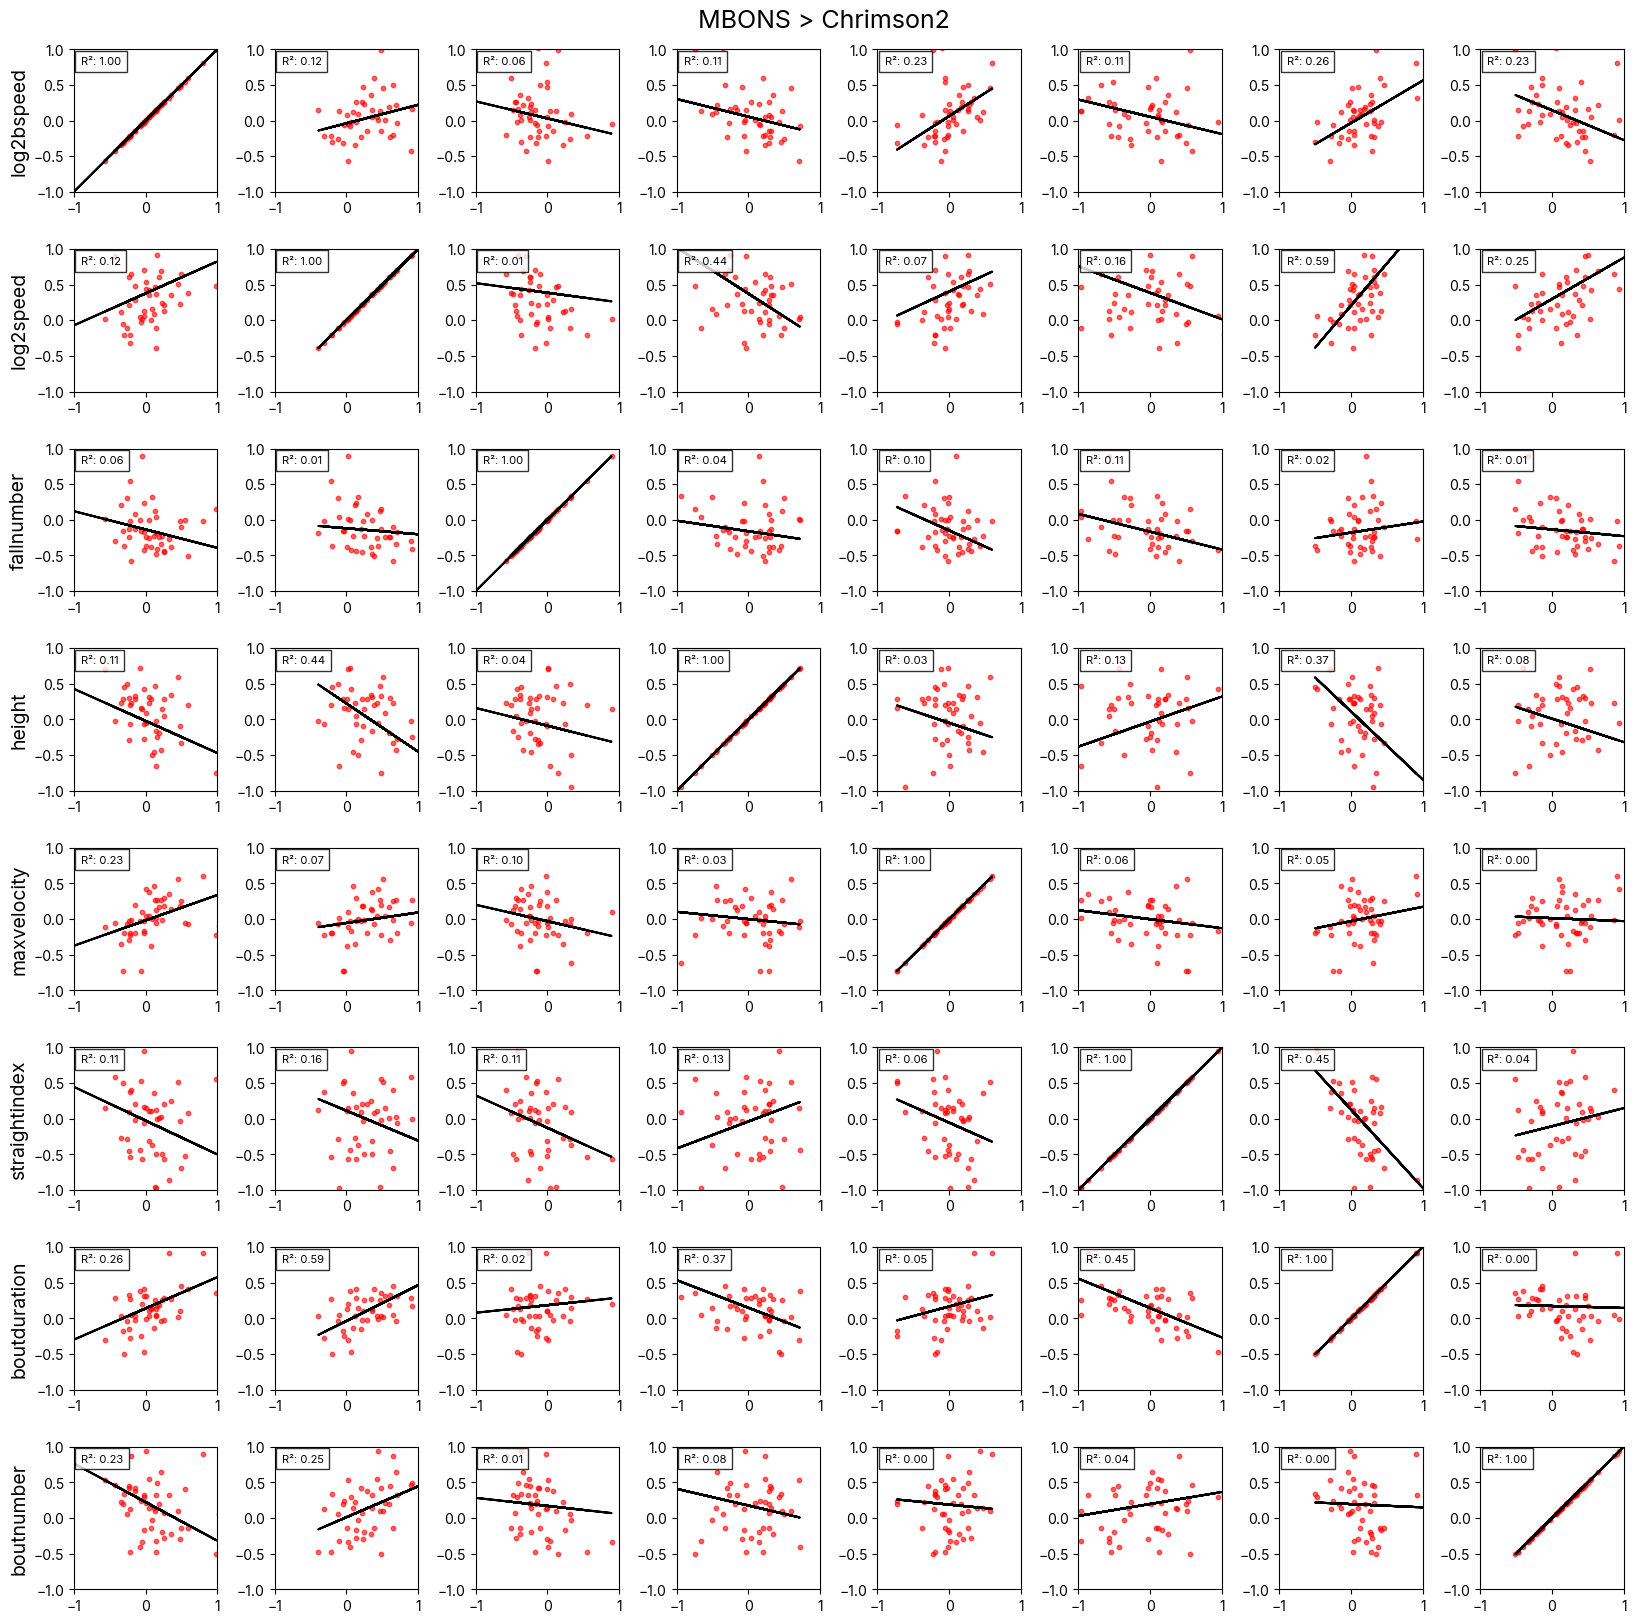

In [ ]:
# Create a figure and axis grid

fig, axes = plt.subplots(8, 8, figsize=(20, 20), gridspec_kw={'wspace': 0.4, 'hspace': 0.4})

df_linreg = df_specificmbon.drop(['responder', 'MBON'], axis =1)
df_linreg.columns = [col.split('_')[0] for col in df_linreg.columns]

# Plot scatter plots for every combination of metrics
for i in range(len(df_linreg.columns)):
    for j in range(len(df_linreg.columns)):
        ax = axes[i, j]
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        ax.scatter(x, y, alpha=0.6, c = "r", s=10)  # Scatter plot
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Add line of best fit
        ax.plot(x, slope * x + intercept, color='black')  # Regression line
        
        # Annotate with R² value
        ax.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                bbox=dict(facecolor='white', alpha=0.8))
        
        # Set axis labels
        if i == 8:  # Add x-axis labels only for the bottom row
            ax.set_xlabel(df_linreg.columns[j], fontsize = 12)
        if j == 0:  # Add y-axis labels only for the first column
            ax.set_ylabel(df_linreg.columns[i], fontsize = 14)

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
# Remove empty space between subplots
plt.tight_layout()

fig.suptitle("MBONS > " + responder, fontsize = 18, y = 0.90)

# Show the plot
plt.show()

## lin reg single metric

In [106]:
responder = "ACR"

onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
                   'responder', 'genotypeandresponder']

eightmetrics = pd.DataFrame()
for p in specificmetrics:
    eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
eightmetrics = eightmetrics.reset_index(drop=True)

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

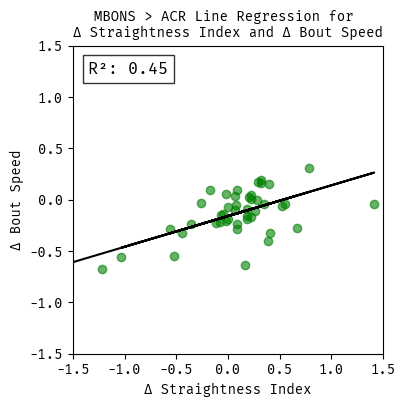

In [115]:
x = df_specificmbon['meanpause_deltag']
y = df_specificmbon['bspeed_deltag']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Create the scatter plot
plt.figure(figsize=(4, 4))
plt.scatter(x, y, c = 'g', alpha=0.6, label='Data Points')  # Scatter plot

# Add the line of best fit
plt.plot(x, slope * x + intercept, color='black', label='Line of Best Fit')  # Regression line

# Annotate with R² value
plt.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
xtitle = 'Δ Straightness Index'
ytitle = 'Δ Bout Speed'
plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.title('MBONS > ' + responder + " Line Regression for \n" + xtitle + " and " + ytitle, fontsize = 10)


# Show the plot
plt.show()

In [ ]:
# import scipy.stats
# fig2, ax2 = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')
# labels = [ ' \n '.join(wrap(l, 12)) for l in df_specificmbon.columns[:-2].tolist()]

# for c,(n,leg) in enumerate(zip(df_specificmbon.columns[:-2].tolist(),8*[False]+[True])):  #by number of metrics
#     spare = pd.DataFrame()
#     spare[n] = matchinglobesets(df_specificmbon, lobelocation)[n]
#     spare['NT'] = matchinglobesets(df_specificmbon, lobelocation)['Neurotransmitter']
#     sns.regplot(x="Chrimson2", y="Chrimson2", data=spare, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=ax2[c]) 
#     sns.scatterplot(x="Chrimson2", y="Chrimson2", data=spare, hue='NT', s = 3, ax = ax2[c], legend = leg)
#     ax2[c].set_xlim([-2,2])
#     ax2[c].set_ylim([-2,2])
#     ax2[c].set_xlabel(labels[c])
#     ax2[c].set_ylabel("")
    
#     #pearsons correlation
#     pearsonscorrelation = scipy.stats.pearsonr(df_specificmbon[n], df_specificmbon[n]) #correlation instead of linear regression: trying to find the relationship rather than causation    
#     civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
#     civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]   
#     ax2[c].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.45, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 8)

# fig2.supxlabel("ACR", weight = "bold")
# fig2.supylabel("Chrimson2", weight = "bold")
# fig2.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

# new_labels = ['Glutamate', 'Acetylcholine', 'GABA', 'Acetylcholine, GABA']
# legend_handles, _= ax2[c].get_legend_handles_labels()
# lgd = fig2.legend(legend_handles, new_labels, 
#           bbox_to_anchor=(1,1), ncol = 4, frameon = False)
# ax2[c].get_legend().set_visible(False)

# #plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

In [ ]:
import scipy.stats
fig7, ax7 = plt.subplots(nrows = 8, ncols = 8, figsize = (10, 10), sharey = True, sharex = True, layout= 'constrained')

for name,row,col in zip(dfreg_a['MBON'], 5*list(range(0,5)), 5*[0]+5*[1]+5*[2]+5*[3]+ 5*[4] +5*[5]):
    df_meltedreg = pd.melt(df_lregmbon[(df_lregmbon['MBON'] == name)], id_vars = ['responder', "MBON"])   
    df_a1= df_meltedreg[(df_meltedreg['responder'] == 'Cr2')]
    df_c1=df_meltedreg[(df_meltedreg['responder'] == 'ACR')]
    
    ax7[row][col].scatter(x= df_a1['value'], y = df_c1['value'],
                color='grey',
                edgecolors="r",
                alpha=0.8,
                s=30)
    
    sns.regplot(x= df_a1['value'], y = df_c1['value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                ax=ax7[row][col],
                truncate=False)

    ax7[row][col].set(xlabel=None)
    ax7[row][col].set(ylabel=None)
    ax7[row][col].set_ylim(-2.1,2.1)  
    ax7[row][col].set_xlim(-2.1,2.1) 
    ax7[row][col].set_title(name, fontsize = 12)

    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(df_a1['value'], df_c1['value']) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]
    ax7[row][col].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.55, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 9)

    
fig7.supxlabel("ACR", weight = "bold")
fig7.supylabel("Chrimson2", weight = "bold")
fig7.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheckMBON.png", dpi = 1200, bbox_inches='tight')

## Lin regression grouped by circles (not updated)

In [ ]:
from sklearn.cluster import SpectralClustering
# fig3, axthree = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')


for c,(n,leg) in enumerate(zip(dfreg_a.columns[:-2].tolist(),8*[False]+[True])):
    fig3, axthree = plt.subplots(figsize = (4, 4))
    
    spare = pd.DataFrame()
    spare["ACR"] = matchinglobesets(dfreg_a, lobelocation)[n]
    spare['Chrimson2'] = matchinglobesets(dfreg_c, lobelocation)[n]
    spare['NT'] = matchinglobesets(dfreg_c, lobelocation)['Neurotransmitter']
    
    #kmeans
    kmeans = SpectralClustering(n_clusters=3)
    clusters = kmeans.fit_predict(spare.iloc[:,0:2])
    cluster = ['k-means_c_' + str(c) for c in clusters]
    X = spare.iloc[:,0:2]
    ogdots = ['#d90429','#f7b267', '#89fc00', '#735751'] #neurotransmitters : red, orange, green, brown
    clusterdots = ["#03045e", '#0077b6', "#00b4d8", "#90e0ef"] #clustering patterns :blue
    
    #neto = sns.scatterplot(x="ACR", y="Chrimson2", data=spare, hue='NT', s = 80, edgecolor = "none", palette = ogdots , legend = True)
    sns.scatterplot(x="ACR", y="Chrimson2", data=X.iloc[:,0:2].assign(cluster = cluster), hue='cluster', palette = clusterdots, legend = False, s = 40, edgecolor = "none")
           
    axthree.set_xlim([-2,2])
    axthree.set_ylim([-2,2])
    axthree.set_xlabel("")
    axthree.set_ylabel("")
    plt.yticks(fontsize=6)
    plt.xticks(fontsize=6)
    

    fig3.supxlabel("ACR", fontsize = 8,  weight = "bold")
    fig3.supylabel("Chrimson2", fontsize = 8, weight = "bold")
    fig3.suptitle(n, fontsize = 12, weight="bold")
    plt.legend(loc=2, prop={'size': 8})
#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

In [ ]:
df_completeresponder = pd.concat([dfreg_a, dfreg_c])
df_lregmbon = df_completeresponder.sort_values(['MBON']).reset_index(drop=True)

In [ ]:
fig7, ax7 = plt.subplots(nrows = 5, ncols = 5, figsize = (10, 10), sharey = True, sharex = True, layout= 'constrained')
for name,row,col in zip(dfreg_a['MBON'], 5*list(range(0,5)), 5*[0]+5*[1]+5*[2]+5*[3]+ 5*[4] +5*[5]):
    df_meltedreg = pd.melt(df_lregmbon[(df_lregmbon['MBON'] == name)], id_vars = ['responder', "MBON"])   
    df_a1= df_meltedreg[(df_meltedreg['responder'] == 'Cr2')]
    df_c1=df_meltedreg[(df_meltedreg['responder'] == 'ACR')]
    
    ax7[row][col].scatter(x= df_a1['value'], y = df_c1['value'],
                color='grey',
                edgecolors="r",
                alpha=0.8,
                s=30)
    
    sns.regplot(x= df_a1['value'], y = df_c1['value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                ax=ax7[row][col],
                truncate=False)

    ax7[row][col].set(xlabel=None)
    ax7[row][col].set(ylabel=None)
    ax7[row][col].set_ylim(-2.1,2.1)  
    ax7[row][col].set_xlim(-2.1,2.1) 
    ax7[row][col].set_title(name, fontsize = 12)

    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(df_a1['value'], df_c1['value']) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]
    ax7[row][col].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.55, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 9)

    
fig7.supxlabel("ACR", weight = "bold")
fig7.supylabel("Chrimson2", weight = "bold")
fig7.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheckMBON.png", dpi = 1200, bbox_inches='tight')